### What's Lambert W?

Lambert W is defined as the inverse of:
$$
ye^y = x \iff y = W(x) 
$$

For real x:

- Principal branch $W_0(x)$: defined for 
$$
x \ge -\frac{1}{e}, \qquad W_0(x) \ge -1
$$

- Lower branch $W_{-1}(x)$: defined for 
$$
-\frac{1}{e} \le x < 0, \qquad W_0(x) \le -1
$$

They meet at the branch point:

$$
(x, y) = \left(-\frac{1}{e}, -1 \right)
$$

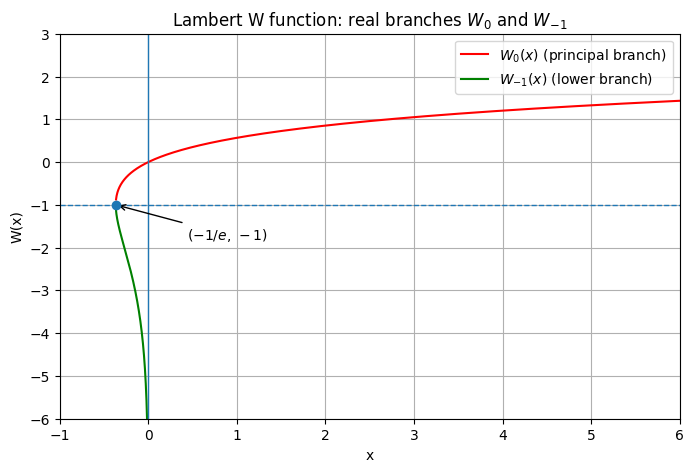

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import lambertw

# --- Domains ---
# Real branches exist for x >= -1/e
x0 = np.linspace(-1/np.e, 6.0, 2000)             # W0 is real on [-1/e, +inf)
x_m1 = np.linspace(-1/np.e, -1e-12, 2000)        # W_{-1} is real on [-1/e, 0)

# --- Compute branches (take real part; imaginary should be ~0 on these domains) ---
W0 = lambertw(x0, k=0).real
Wm1 = lambertw(x_m1, k=-1).real

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.plot(x0, W0, 'r', label=r"$W_0(x)$ (principal branch)")
plt.plot(x_m1, Wm1, 'g', label=r"$W_{-1}(x)$ (lower branch)")

# Branch point (-1/e, -1)
xb = -1/np.e
yb = -1.0
plt.scatter([xb], [yb], zorder=5)
plt.annotate(r"$(-1/e,\,-1)$", xy=(xb, yb), xytext=(xb+0.8, yb-0.8),
             arrowprops=dict(arrowstyle="->"))

plt.axvline(0, linewidth=1)
plt.axhline(-1, linewidth=1, linestyle="--")

plt.xlim(-1.0, 6.0)
plt.ylim(-6.0, 3.0)
plt.xlabel("x")
plt.ylabel("W(x)")
plt.title("Lambert W function: real branches $W_0$ and $W_{-1}$")
plt.legend()
plt.grid(True)
plt.show()

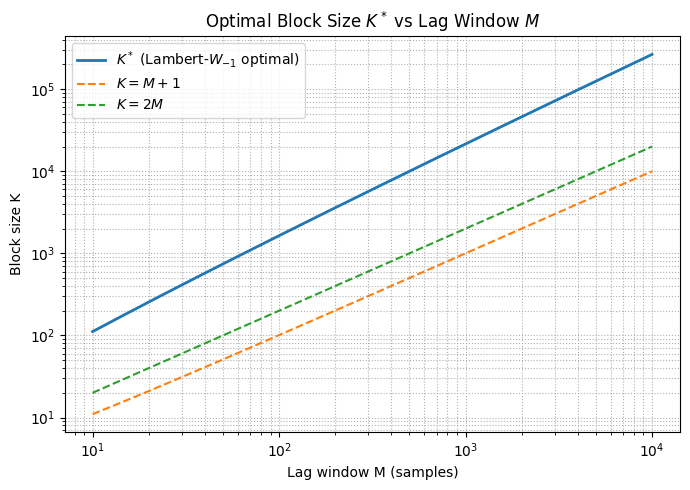

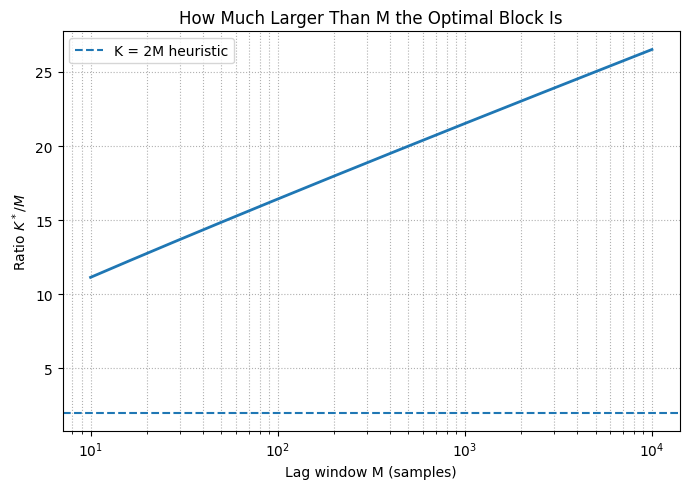

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import lambertw

# ---- Define K*(M) from Zhang (2025) ----
def K_star(M):
    """
    Optimal block size from Zhang (2025):
        K* = 2M(-W_{-1}(-1/(4eM)) - 1)
    """
    M = np.asarray(M, dtype=float)
    z = -1.0 / (4.0 * np.e * M)
    Wm1 = lambertw(z, k=-1).real   # lower branch
    return 2.0 * M * (-Wm1 - 1.0)

# ---- Range of M values (log-scale is most informative) ----
M_vals = np.logspace(1, 4, 300)   # e.g. 10 → 10,000 samples

Kopt = K_star(M_vals)
K_Mp1 = M_vals + 1
K_2M  = 2 * M_vals

# ---- Plot absolute sizes ----
plt.figure(figsize=(7,5))
plt.loglog(M_vals, Kopt, label=r"$K^*$ (Lambert-$W_{-1}$ optimal)", linewidth=2)
plt.loglog(M_vals, K_Mp1, "--", label=r"$K=M+1$")
plt.loglog(M_vals, K_2M, "--", label=r"$K=2M$")

plt.xlabel("Lag window M (samples)")
plt.ylabel("Block size K")
plt.title("Optimal Block Size $K^*$ vs Lag Window $M$")
plt.grid(True, which="both", ls=":")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot ratio K*/M to show scaling ----
plt.figure(figsize=(7,5))
plt.semilogx(M_vals, Kopt / M_vals, linewidth=2)
plt.axhline(2, linestyle="--", label="K = 2M heuristic")

plt.xlabel("Lag window M (samples)")
plt.ylabel(r"Ratio $K^*/M$")
plt.title("How Much Larger Than M the Optimal Block Is")
plt.grid(True, which="both", ls=":")
plt.legend()
plt.tight_layout()
plt.show()

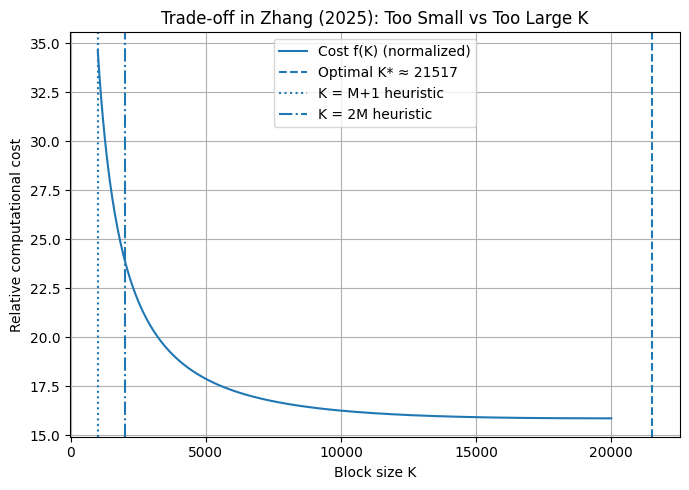

Computed optimal K* ≈ 21517.3  (≈ 21.52 × M)


In [6]:
# Visualization of the cost trade-off f(K) and the optimal K*
# (Uses matplotlib with default styling as required.)

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import lambertw

# --- Problem setup (representative DAS regime) ---
N = 1_000_000   # long record length (only affects scale, not the shape)
M = 1000        # short lag window (M << N)

# Define Zhang cost function (up to constant factor N)
def f_of_K(K, M):
    return (1.0 + 2.0*M/K) * np.log2(K + 2.0*M)

# Optimal K* from Lambert W_{-1}
z = -1.0 / (4.0 * np.e * M)
Wm1 = lambertw(z, k=-1).real
K_star = 2.0 * M * (-Wm1 - 1.0)

# Range of K values to visualize trade-off
K_vals = np.linspace(M+1, 20*M, 600)
cost_vals = f_of_K(K_vals, M)

# --- Plot ---
plt.figure(figsize=(7,5))
plt.plot(K_vals, cost_vals, label="Cost f(K) (normalized)")
plt.axvline(K_star, linestyle="--", label=f"Optimal K* ≈ {int(K_star)}")
plt.axvline(M+1, linestyle=":", label="K = M+1 heuristic")
plt.axvline(2*M, linestyle="-.", label="K = 2M heuristic")

plt.xlabel("Block size K")
plt.ylabel("Relative computational cost")
plt.title("Trade-off in Zhang (2025): Too Small vs Too Large K")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Computed optimal K* ≈ {K_star:.1f}  (≈ {K_star/M:.2f} × M)")
